<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation1/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [2]:
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

3. Split the Dataset

Split the data into training and testing sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [6]:
# Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 77.44%
Confusion Matrix:
 [[56 16]
 [14 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        72
           1       0.75      0.77      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.78      0.77      0.77       133



In [7]:
# printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [1.47532634] [-1.67518769] [0.52654523]


# 2nd Logistic Regersion

This model is from the Applied Machine Learning with Python book-page 62

In [8]:
X = data.data
y = data.target
print(data.feature_names)
print(data.DESCR)


['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, bloo

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 80.45%
Confusion Matrix:
 [[56 16]
 [10 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81        72
           1       0.76      0.84      0.80        61

    accuracy                           0.80       133
   macro avg       0.80      0.81      0.80       133
weighted avg       0.81      0.80      0.80       133



### Comparing Coefficients of Scaled vs. Unscaled Models

In [12]:
print('Prediction:', lr.predict(X_test)[1], lr.predict(X_test)[9], lr.predict(X_test)[25])
print('Raw Model Output X_test: ',
      (lr.coef_@ X_test[1] + lr.intercept_),
      (lr.coef_@ X_test[9] + lr.intercept_),
      (lr.coef_@ X_test[25]+ lr.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [0.1352537] [-0.09852356] [0.17023003]


In [13]:
print("Scaled Model (model):")
print("  Coefficients:", model.coef_)
print("  Intercept:", model.intercept_)

print("\nUnscaled Model (lr):")
print("  Coefficients:", lr.coef_)
print("  Intercept:", lr.intercept_)

Scaled Model (model):
  Coefficients: [[ 0.10500243 -0.58724547  0.67459032  0.61835658 -0.32022822 -0.08939562
  -0.52441695  0.09787805  0.62173009 -0.04851767]]
  Intercept: [0.14722282]

Unscaled Model (lr):
  Coefficients: [[ 0.57359398 -0.65002523  2.35591272  1.85001384  0.18766705  0.06003926
  -1.59215119  1.32216707  1.94320318  1.15471231]]
  Intercept: [0.05378309]


# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [17]:
#import important libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import seaborn as sns
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [48]:
# Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data= pd.read_csv("diabetesdb.csv")
diab_data.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


### Understanding the 'glyhb' column

Descriptive statistics for 'glyhb' column:


,glyhb
count,390.000000
mean,5.589769
std,2.242595
min,2.680000
25%,4.380000
50%,4.840000
75%,5.600000
max,16.110001


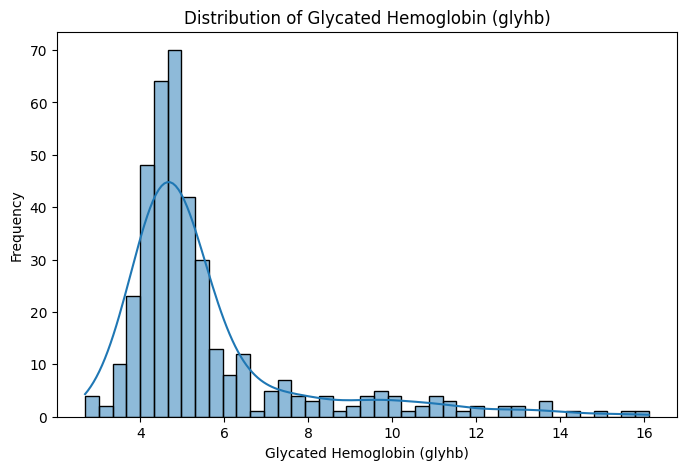

In [49]:
# Display descriptive statistics for 'glyhb'
print("Descriptive statistics for 'glyhb' column:")
display(diab_data['glyhb'].describe())

# Visualize the distribution of 'glyhb'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data['glyhb'].dropna(), kde=True)
plt.title('Distribution of Glycated Hemoglobin (glyhb)')
plt.xlabel('Glycated Hemoglobin (glyhb)')
plt.ylabel('Frequency')
plt.show()

In [50]:
# Cleaning dat
# Droping all missing values
diab_data = diab_data.dropna(how='any')

In [51]:
diab_data.head(20)

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
2,1002,228.0,92,37.0,6.200000,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
6,1011,195.0,92,41.0,4.800000,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
8,1016,177.0,87,49.0,3.600000,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0
10,1024,242.0,82,54.0,4.500000,4.77,Louisa,60,female,65.0,156.0,medium,130.0,90.0,130.0,90.0,39.0,45.0,300.0
15,1036,213.0,83,47.0,4.500000,3.41,Louisa,33,female,65.0,157.0,medium,130.0,90.0,120.0,96.0,37.0,41.0,240.0
20,1252,186.0,97,50.0,3.700000,6.49,Buckingham,70,male,67.0,178.0,large,148.0,88.0,148.0,84.0,42.0,41.0,1020.0
21,1253,234.0,65,76.0,3.100000,4.67,Buckingham,47,male,67.0,230.0,large,137.0,100.0,149.0,110.0,45.0,46.0,480.0
23,1256,281.0,92,41.0,6.900000,5.56,Buckingham,66,female,62.0,185.0,large,158.0,88.0,160.0,88.0,48.0,44.0,285.0
24,1271,228.0,66,45.0,5.100000,4.61,Buckingham,24,female,61.0,113.0,medium,100.0,70.0,110.0,70.0,33.0,38.0,210.0
29,1285,215.0,72,42.0,5.100000,4.37,Louisa,40,male,70.0,189.0,medium,180.0,122.0,170.0,112.0,37.0,39.0,450.0


In [52]:
# Converting string data to number (Location, Gender, and Fram)
gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)

location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)

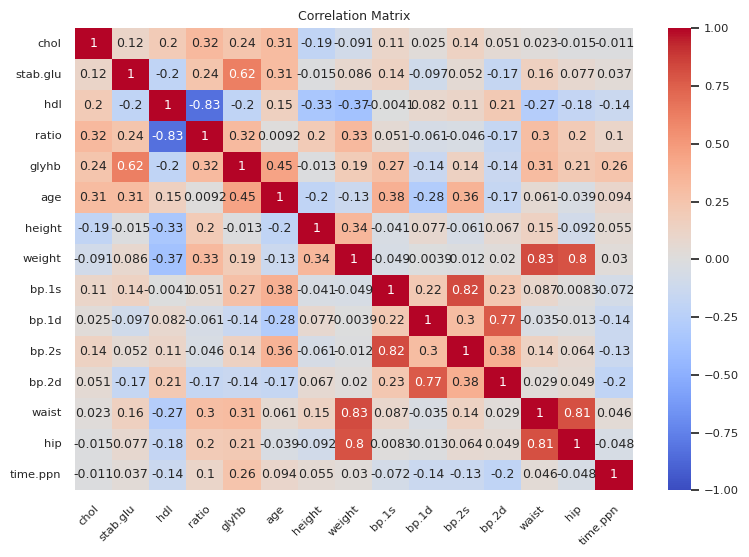

In [75]:
corr = diab_data.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()






-------------------------
# This part is for demo test

---



In [14]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

(442, 10)

In [15]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

# Linear Regression

Mean squared error: 2548.07
Coefficient of determination: 0.47


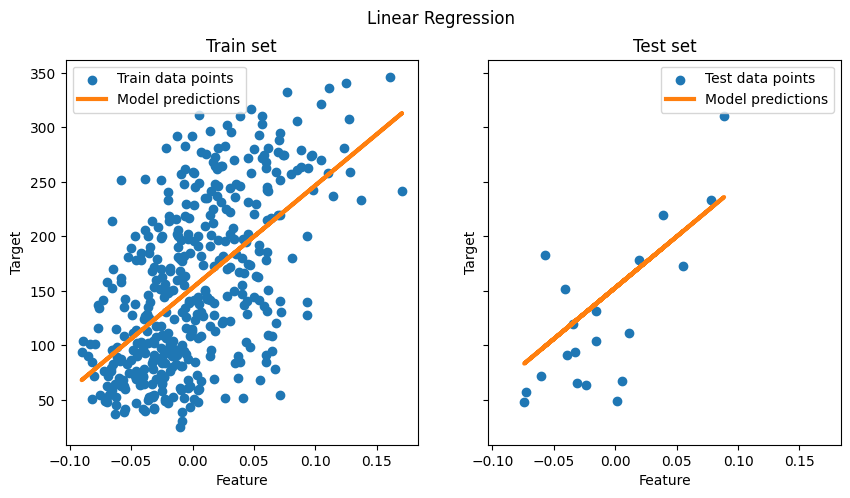

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()